# Stage 06 — Classification (RQ2)

**Owner:** Sandesh Shahi (Analysis Lead)

**Research question.** *Can organisations be classified as high vs low proportion of women in management based on their policy and structural characteristics?*

**Model.** Gaussian Naive Bayes (scikit-learn `GaussianNB`). NB is fast, easy to explain to non-technical stakeholders, and has a well-defined probabilistic output. Its independence assumption is *known* to be violated on our predictor set; we note this as a limitation.

**Statistical comparator (for notebook 07).** A majority-class baseline (`DummyClassifier(strategy="most_frequent")`). The paired-CV t-test in notebook 07 asks whether Naive Bayes beats this baseline by more than random CV variation.

**Evaluation.** Stratified 80/20 split. Metrics: Accuracy, Precision, Recall, F1. The median split guarantees near-balanced classes, so accuracy is meaningful.

**Inputs.** Checkpoints from notebook 03 (feature engineering): `X`, `y_cls`.

**Outputs.**
- `data/processed/checkpoints/06_nb_model.pkl`
- `data/processed/checkpoints/06_cls_metrics.json`
- `outputs/figures/rq2_confusion_matrix.png`

## 1. Setup

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
from IPython.display import Image, display

from src import config, classification, evaluation, visualisation
from src.utils import save_checkpoint

def _load(name):
    p = config.CHECKPOINT_DIR / name
    return pd.read_parquet(p) if p.exists() else pd.read_csv(p.with_suffix('.csv'))

X = _load("03_X.parquet")
y_cls = _load("03_y_cls.parquet").iloc[:, 0]

# Drop any rows where the classification target is NA
mask = y_cls.notna()
X_cls = X.loc[mask].reset_index(drop=True)
y_cls = y_cls.loc[mask].astype(int).reset_index(drop=True)
print("X_cls:", X_cls.shape, "| y_cls:", y_cls.shape)

X_cls: (7971, 24) | y_cls: (7971,)


## 2. Class balance check

Because `women_mgmt_high` is a median split, the two classes should be approximately equal in size — if they're not (e.g. ties on the median push the split off), we'd need to consider `class_weight` or alternative encodings. A big imbalance would also make accuracy misleading, so this check informs metric interpretation.

In [2]:
balance = y_cls.value_counts().rename({0: "Low", 1: "High"})
pct = (balance / balance.sum() * 100).round(1)
print("Class counts:")
print(balance.to_string())
print(f"\nClass proportions: Low = {pct.get('Low', 0)}%   High = {pct.get('High', 0)}%")
print("→ Near-balanced; accuracy is a reasonable headline metric.")

Class counts:
women_mgmt_high
Low     4010
High    3961

Class proportions: Low = 50.3%   High = 49.7%
→ Near-balanced; accuracy is a reasonable headline metric.


## 3. Fit Gaussian Naive Bayes

Stratified 80/20 split (defined in `src.classification._split`) preserves class ratios in both train and test.

In [3]:
nb_res = classification.fit_naive_bayes(X_cls, y_cls)
nb_metrics = evaluation.classification_metrics(
    nb_res.y_test.values, nb_res.y_pred_test, nb_res.y_proba_test,
)
print("Naive Bayes — test-set metrics")
for k, v in nb_metrics.items():
    print(f"  {k:10s} = {v:.4f}")

20:43:31 | INFO    | src.classification | NB fitted: 6376 train / 1595 test; class balance=0.50
Naive Bayes — test-set metrics
  Accuracy   = 0.7530
  Precision  = 0.6928
  Recall     = 0.9042
  F1         = 0.7845
  ROC_AUC    = 0.8575


## 4. Confusion matrix

Rows = actual class, columns = predicted class. The diagonal is the count we got right; off-diagonal cells are the two error types (false High / false Low). This is the chart we show to the non-technical audience.

Confusion matrix:
             Pred Low  Pred High
Actual Low        484        318
Actual High        76        717
20:43:31 | INFO    | src.visualisation | Saved rq2_confusion_matrix.png


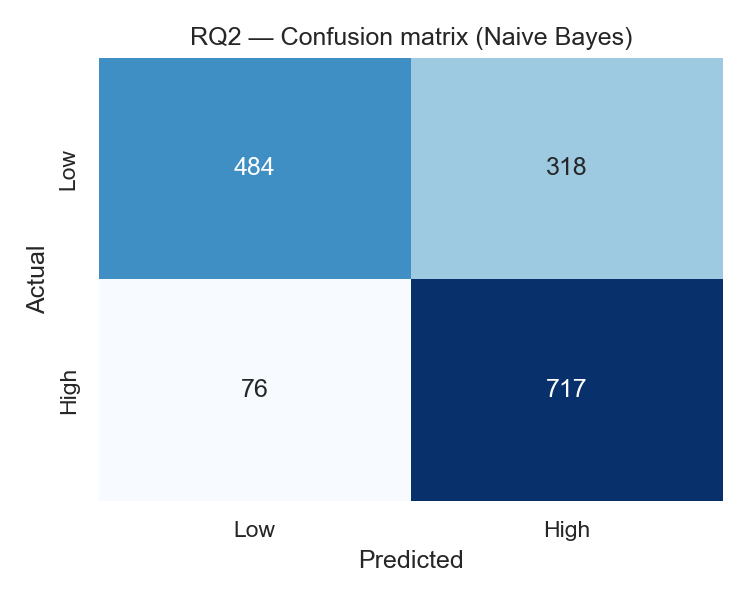

In [4]:
cm = evaluation.confusion(nb_res.y_test.values, nb_res.y_pred_test)
print("Confusion matrix:")
print(pd.DataFrame(cm, index=["Actual Low", "Actual High"],
                   columns=["Pred Low", "Pred High"]))
p_cm = visualisation.plot_confusion_matrix(cm)
display(Image(str(p_cm)))

## 7. Checkpoint

In [5]:
save_checkpoint(nb_res.model, config.CHECKPOINT_DIR / "06_nb_model.pkl")
with open(config.CHECKPOINT_DIR / "06_cls_metrics.json", "w") as f:
    json.dump({"naive_bayes": nb_metrics}, f, indent=2)
print("Saved Naive Bayes model + metrics.")

Saved Naive Bayes model + metrics.


## Takeaways for the slide deck

- Primary headline: NB test-set accuracy / F1, against a near-balanced class split.
- The confusion matrix tells the audience where the errors fall — false High vs false Low — which matters more than the single-number accuracy.
- Whether NB's accuracy beats the majority-class baseline *by more than CV noise* is formally tested in notebook 07 (paired-CV t-test).
- Known limitation: Naive Bayes assumes feature independence; our policy flags are correlated, so we flag this on the limitations slide.

**Next:** `07_statistical_tests.ipynb` — paired-CV t-tests (Simple vs Multiple LR, and NB vs majority baseline).